# 05 - Feature Engineering for Marketing Mix Model

## Objective
Transform the cleaned data into features suitable for MMM modeling:

1. **Media Channel Regrouping** - Consolidate digital channels into meaningful groups
2. **Adstock Transformations** - Model carryover/memory effects of advertising
3. **Saturation/Diminishing Returns** - Apply non-linear transformations
4. **Lag Features** - Capture delayed response effects
5. **Seasonality Controls** - Create seasonal indicators
6. **Scaling & Normalization** - Prepare features for modeling

## Target Variables
Focus on three main product categories:
- **Piscines Hors Terre** (Above-ground pools)
- **Piscines Creusées** (In-ground pools)  
- **Spas**

## Media Channel Grouping Strategy
Given limited historical data (~2 years monthly), we consolidate channels:
1. **Television** - TV
2. **Audio** - Radio + Radio Numérique (similar consumption logic)
3. **Affichage** - Panneaux + Affichages Numériques (outdoor)
4. **Search** - Google Ads
5. **Digital Branding** - Bannières Web Premium, La Presse, Contenu de Marque, Preroll
6. **Circulaire Digital** - Standalone (meaningful spend)

---

In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import zscore
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_palette('husl')

# Paths
project_root = Path().cwd().parent if Path().cwd().name == 'notebooks' else Path().cwd()
processed_path = project_root / 'data' / 'processed'
figures_path = project_root / 'reports' / 'figures'

print(f"Loading data from: {processed_path}")
print(f"Saving figures to: {figures_path}")

Loading data from: /Users/raoul/Dev/busa693-clubpiscine/data/processed
Saving figures to: /Users/raoul/Dev/busa693-clubpiscine/reports/figures


In [2]:
# Cell 2: Load the merged dataset with weather
df = pd.read_pickle(processed_path / 'quotes_spend_weather.pkl')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
print(f"\nColumns: {df.columns.tolist()}")

Dataset loaded successfully!
Shape: (19, 46)
Date range: 2024-01-01 00:00:00 to 2025-09-01 00:00:00

Columns: ['year', 'month', 'month_num', 'piscines_hors_terre', 'piscines_creusees', 'spas', 'autres_produits', 'services', 'autre', 'total_main_quotes', 'total_all_quotes', 'date', 'spend_bannières_web___premium', 'spend_circulaire_digital', 'spend_circulaire_digitale', 'spend_contenu_de_marque', 'spend_google_ads', 'spend_google_shopping', 'spend_lapresse_(lp+,_preroll,_display)', 'spend_panneaux', 'spend_panneaux_et_affichages_numériques', 'spend_preroll___premium', 'spend_radio', 'spend_radio_numérique', 'spend_social_media', 'spend_television', 'spend_total', 'avg_temp_max', 'avg_temp_min', 'avg_temp_mean', 'total_precipitation', 'total_sunshine_hours', 'days_above_15', 'days_above_20', 'days_above_25', 'rain_days', 'heating_degree_days', 'cooling_degree_days', 'rolling_temp_7d_eom', 'n_holidays', 'holiday_end_season', 'holiday_low', 'holiday_peak', 'holiday_pool_closing', 'holiday_

# 05 - Feature Engineering for Marketing Mix Model

## Objective
Transform the cleaned data into features suitable for MMM modeling:

1. **Media Channel Setup** - Use 7 strategic channel groups
2. **Adstock Transformations** - Model carryover/memory effects of advertising
3. **Saturation/Diminishing Returns** - Apply non-linear transformations
4. **Lag Features** - Capture delayed response effects
5. **Seasonality Controls** - Create seasonal indicators
6. **Scaling & Normalization** - Prepare features for modeling

## Target Variables
Focus on three main product categories:
- **Piscines Hors Terre** (Above-ground pools)
- **Piscines Creusées** (In-ground pools)  
- **Spas**

## Media Channel Groups (7 channels)
1. **Television** - TV
2. **Audio** - Radio + Radio Numérique
3. **Affichage** - Panneaux + Affichages Numériques
4. **Search** - Google Ads + Shopping
5. **Digital_Branding** - Bannières Web Premium, La Presse, Contenu de Marque, Preroll
6. **Circulaire_Digital** - Digital flyers
7. **Social_Media** - Facebook + Instagram + Pinterest + TikTok

---

In [3]:
# Cell 3: Identify or Create Media Channel Columns

def setup_media_channels(df):
    """
    Identify or create the 7 media channel columns.
    
    If data comes from cleaning v2 (with 7-channel grouping), columns will be:
    - spend_television, spend_audio, spend_affichage, spend_search, 
    - spend_digital_branding, spend_circulaire_digital, spend_social_media
    
    If data comes from older cleaning, we regroup from granular channels.
    """
    df = df.copy()
    
    # Check if new 7-channel format exists
    new_format_cols = ['spend_television', 'spend_audio', 'spend_affichage', 
                       'spend_search', 'spend_digital_branding', 
                       'spend_circulaire_digital', 'spend_social_media']
    
    if all(c in df.columns for c in new_format_cols):
        print("✓ Using 7-channel format from cleaning v2")
        # Rename to media_ prefix for consistency
        for col in new_format_cols:
            new_name = col.replace('spend_', 'media_')
            df[new_name] = df[col]
        media_cols = ['media_television', 'media_audio', 'media_affichage', 
                      'media_search', 'media_digital_branding', 
                      'media_circulaire_digital', 'media_social_media']
    else:
        print("✓ Regrouping from granular channels (older format)")
        # Fallback: regroup from granular channels
        
        # 1. Television
        tv_cols = [c for c in df.columns if 'television' in c.lower() and 'spend' in c.lower()]
        df['media_television'] = df[tv_cols].sum(axis=1) if tv_cols else 0
        
        # 2. Audio (Radio + Radio Numérique)
        audio_cols = [c for c in df.columns if 'radio' in c.lower() and 'spend' in c.lower()]
        df['media_audio'] = df[audio_cols].sum(axis=1) if audio_cols else 0
        
        # 3. Affichage (Panneaux + Affichages Numériques)
        affichage_cols = [c for c in df.columns if ('panneau' in c.lower() or 'affichage' in c.lower()) and 'spend' in c.lower()]
        df['media_affichage'] = df[affichage_cols].sum(axis=1) if affichage_cols else 0
        
        # 4. Search (Google)
        search_cols = [c for c in df.columns if 'google' in c.lower() and 'spend' in c.lower()]
        df['media_search'] = df[search_cols].sum(axis=1) if search_cols else 0
        
        # 5. Digital Branding
        digital_patterns = ['bannière', 'premium', 'lapresse', 'presse', 'contenu', 'preroll']
        digital_cols = [c for c in df.columns if any(p in c.lower() for p in digital_patterns) 
                        and 'spend' in c.lower() and 'circulaire' not in c.lower()]
        df['media_digital_branding'] = df[digital_cols].sum(axis=1) if digital_cols else 0
        
        # 6. Circulaire Digital
        circ_cols = [c for c in df.columns if 'circulaire' in c.lower() and 'spend' in c.lower()]
        df['media_circulaire_digital'] = df[circ_cols].sum(axis=1) if circ_cols else 0
        
        # 7. Social Media
        social_cols = [c for c in df.columns if 'social' in c.lower() and 'spend' in c.lower()]
        df['media_social_media'] = df[social_cols].sum(axis=1) if social_cols else 0
        
        media_cols = ['media_television', 'media_audio', 'media_affichage', 
                      'media_search', 'media_digital_branding', 
                      'media_circulaire_digital', 'media_social_media']
    
    # Calculate total
    df['media_total'] = df[media_cols].sum(axis=1)
    
    return df, media_cols

# Apply channel setup
df, media_channels = setup_media_channels(df)

print("=" * 70)
print("MEDIA CHANNELS CONFIGURED (7 Groups)")
print("=" * 70)

print("\nChannel groups:")
for ch in media_channels:
    total = df[ch].sum()
    pct = total / df['media_total'].sum() * 100 if df['media_total'].sum() > 0 else 0
    print(f"  {ch}: ${total:,.0f} ({pct:.1f}%)")

print(f"\nTotal: ${df['media_total'].sum():,.0f}")

✓ Regrouping from granular channels (older format)
MEDIA CHANNELS CONFIGURED (7 Groups)

Channel groups:
  media_television: $1,917,568 (35.5%)
  media_audio: $1,378,406 (25.6%)
  media_affichage: $178,784 (3.3%)
  media_search: $645,832 (12.0%)
  media_digital_branding: $662,733 (12.3%)
  media_circulaire_digital: $199,799 (3.7%)
  media_social_media: $411,270 (7.6%)

Total: $5,394,392


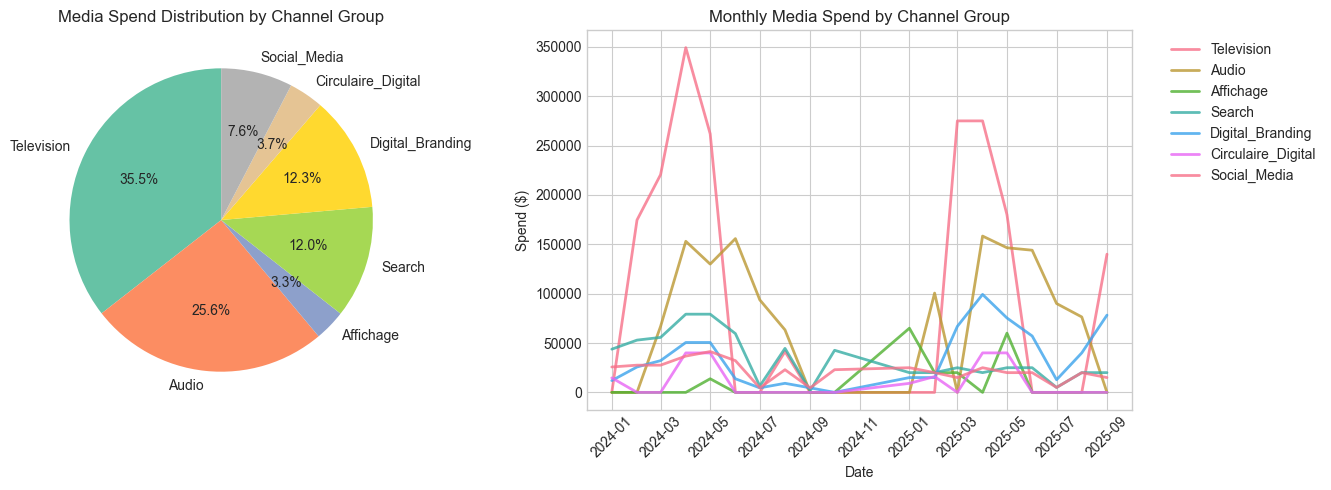

In [4]:
# Cell 4: Visualize Channel Spend Distribution

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart of total spend by channel
channel_totals = df[media_channels].sum()
ax1 = axes[0]
colors = plt.cm.Set2(np.linspace(0, 1, len(media_channels)))
wedges, texts, autotexts = ax1.pie(channel_totals, labels=[c.replace('media_', '').title() for c in media_channels],
                                    autopct='%1.1f%%', colors=colors, startangle=90)
ax1.set_title('Media Spend Distribution by Channel Group')

# Time series of spend by channel
ax2 = axes[1]
df_sorted = df.sort_values('date')
for i, ch in enumerate(media_channels):
    ax2.plot(df_sorted['date'], df_sorted[ch], label=ch.replace('media_', '').title(), 
             linewidth=2, alpha=0.8)
ax2.set_xlabel('Date')
ax2.set_ylabel('Spend ($)')
ax2.set_title('Monthly Media Spend by Channel Group')
ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(figures_path / 'media_channel_groups.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Adstock Transformations

Advertising has **carryover effects** - exposure today influences behavior in future periods.

### Geometric Adstock Formula:
$$Adstock_t = Spend_t + \lambda \cdot Adstock_{t-1}$$

Where $\lambda$ (decay rate) is between 0 and 1:
- **High decay (λ ≈ 0.1-0.3)**: Short memory - Digital, Search
- **Medium decay (λ ≈ 0.4-0.6)**: Moderate memory - Radio, Circulaire
- **Low decay (λ ≈ 0.6-0.8)**: Long memory - TV, Branding

### Channel-Specific Decay Rates:
Based on industry research and channel characteristics:
- **Television**: λ = 0.7 (strong brand building, long memory)
- **Audio**: λ = 0.5 (moderate retention)
- **Affichage**: λ = 0.4 (outdoor exposure fades)
- **Search**: λ = 0.2 (immediate intent, short memory)
- **Digital Branding**: λ = 0.5 (display ads, moderate memory)
- **Circulaire Digital**: λ = 0.3 (promotional, shorter memory)

In [5]:
# Cell 5: Adstock Transformation Functions

def geometric_adstock(x, decay_rate):
    """
    Apply geometric adstock transformation.
    
    Parameters:
    -----------
    x : array-like
        Time series of spend values (must be sorted by time)
    decay_rate : float
        Decay rate lambda between 0 and 1
        Higher = longer memory
    
    Returns:
    --------
    array : Adstocked values
    """
    x = np.array(x)
    adstocked = np.zeros(len(x))
    adstocked[0] = x[0]
    
    for t in range(1, len(x)):
        adstocked[t] = x[t] + decay_rate * adstocked[t-1]
    
    return adstocked


def weibull_adstock(x, decay_rate, shape=1.5, max_lag=8):
    """
    Apply Weibull (delayed) adstock - allows for peak effect after exposure.
    Useful for channels where impact builds before decaying.
    """
    from scipy.stats import weibull_min
    
    x = np.array(x)
    n = len(x)
    
    lags = np.arange(max_lag)
    weights = weibull_min.pdf(lags, c=shape, scale=decay_rate)
    weights = weights / weights.sum()
    
    adstocked = np.convolve(x, weights, mode='full')[:n]
    
    return adstocked


# Define decay rates by channel (based on industry benchmarks)
DECAY_RATES = {
    'media_television': 0.7,         # Strong brand building, long memory
    'media_audio': 0.5,              # Moderate retention
    'media_affichage': 0.4,          # Outdoor fades
    'media_search': 0.2,             # Immediate intent, short memory
    'media_digital_branding': 0.5,   # Display moderate
    'media_circulaire_digital': 0.3, # Promotional short
    'media_social_media': 0.4,       # Social engagement, moderate memory
}

print("Decay rates by channel:")
for ch, rate in DECAY_RATES.items():
    half_life = np.log(0.5) / np.log(rate) if rate > 0 else 0
    print(f"  {ch.replace('media_', '')}: λ={rate} (half-life ≈ {half_life:.1f} periods)")

Decay rates by channel:
  television: λ=0.7 (half-life ≈ 1.9 periods)
  audio: λ=0.5 (half-life ≈ 1.0 periods)
  affichage: λ=0.4 (half-life ≈ 0.8 periods)
  search: λ=0.2 (half-life ≈ 0.4 periods)
  digital_branding: λ=0.5 (half-life ≈ 1.0 periods)
  circulaire_digital: λ=0.3 (half-life ≈ 0.6 periods)
  social_media: λ=0.4 (half-life ≈ 0.8 periods)


In [6]:
# Cell 6: Apply Adstock Transformations

# Sort by date to ensure proper time ordering
df = df.sort_values('date').reset_index(drop=True)

# Apply adstock to each channel
for channel in media_channels:
    decay_rate = DECAY_RATES.get(channel, 0.5)  # Default to 0.5 if not specified
    adstock_col = f"{channel}_adstock"
    df[adstock_col] = geometric_adstock(df[channel].fillna(0), decay_rate)

# Show comparison for one channel
print("=" * 70)
print("ADSTOCK TRANSFORMATION EXAMPLE: Television")
print("=" * 70)
print(df[['date', 'media_television', 'media_television_adstock']].head(12).to_string(index=False))

# List all adstock columns
adstock_cols = [c for c in df.columns if '_adstock' in c]
print(f"\nAdstock columns created: {len(adstock_cols)}")
for col in adstock_cols:
    print(f"  - {col}")

ADSTOCK TRANSFORMATION EXAMPLE: Television
      date  media_television  media_television_adstock
2024-01-01          0.000000                  0.000000
2024-02-01     174594.594595             174594.594595
2024-03-01     220540.540541             342756.756757
2024-04-01     349189.189189             589118.918919
2024-05-01     261891.891892             674275.135135
2024-06-01          0.000000             471992.594595
2024-07-01          0.000000             330394.816216
2024-08-01      41351.351351             272627.722703
2024-09-01          0.000000             190839.405892
2024-10-01          0.000000             133587.584124
2025-01-01          0.000000              93511.308887
2025-02-01          0.000000              65457.916221

Adstock columns created: 7
  - media_television_adstock
  - media_audio_adstock
  - media_affichage_adstock
  - media_search_adstock
  - media_digital_branding_adstock
  - media_circulaire_digital_adstock
  - media_social_media_adstock


IndexError: index 6 is out of bounds for axis 0 with size 6

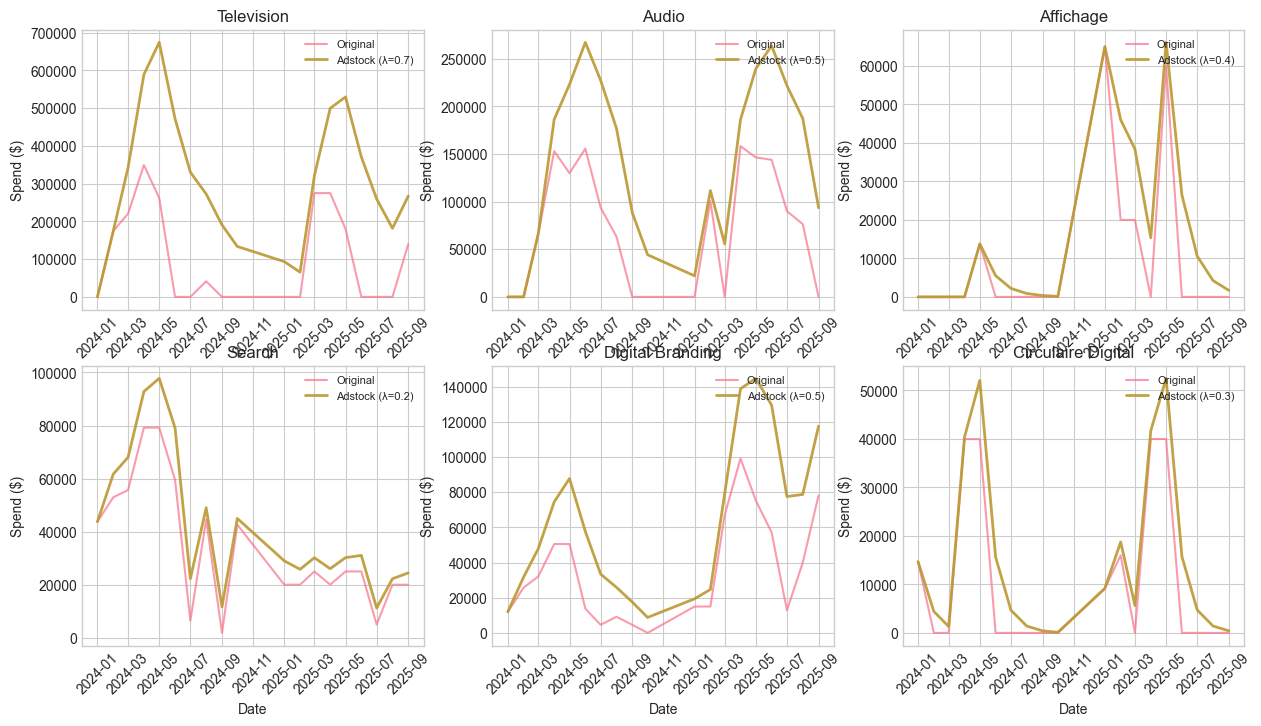

In [7]:
# Cell 7: Visualize Adstock Effect

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, channel in enumerate(media_channels):
    ax = axes[idx]
    adstock_col = f"{channel}_adstock"
    
    ax.plot(df['date'], df[channel], label='Original', alpha=0.7, linewidth=1.5)
    ax.plot(df['date'], df[adstock_col], label=f'Adstock (λ={DECAY_RATES[channel]})', 
            alpha=0.9, linewidth=2)
    
    ax.set_title(channel.replace('media_', '').replace('_', ' ').title())
    ax.set_xlabel('Date')
    ax.set_ylabel('Spend ($)')
    ax.legend(loc='upper right', fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Adstock Transformation: Original vs Transformed Spend', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(figures_path / 'adstock_transformation.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Saturation / Diminishing Returns

Media effectiveness exhibits **diminishing returns** - doubling spend doesn't double impact.

### Transformation Options:

**1. Log Transformation (Simple):**
$$y = \log(1 + x)$$

**2. Hill Function (S-curve):**
$$y = \frac{x^\alpha}{x^\alpha + K^\alpha}$$
- K = half-saturation point (spend level at 50% effect)
- α = steepness (higher = sharper S-curve)

**3. Power Function:**
$$y = x^\beta$$ where $0 < \beta < 1$

### Recommended Approach:
For monthly data with limited observations, we use:
- **Hill function** for channels with clear saturation (TV, traditional)
- **Log transformation** as a simpler alternative for comparison

In [ ]:
# Cell 8: Saturation Functions

def log_saturation(x, scale=1):
    """
    Simple log transformation for diminishing returns.
    
    Parameters:
    -----------
    x : array-like
        Spend values
    scale : float
        Scaling factor (default 1)
    """
    return np.log1p(x / scale)


def hill_saturation(x, K, alpha=2):
    """
    Hill function for S-curve saturation.
    
    Parameters:
    -----------
    x : array-like
        Spend values (or adstocked spend)
    K : float
        Half-saturation point (spend level at 50% max effect)
    alpha : float
        Steepness parameter (higher = sharper curve)
    """
    x = np.array(x)
    return np.where(x > 0, x**alpha / (x**alpha + K**alpha), 0)


def power_saturation(x, beta=0.5):
    """
    Power function for diminishing returns.
    
    Parameters:
    -----------
    x : array-like
        Spend values
    beta : float
        Power parameter (0 < beta < 1 for diminishing returns)
    """
    x = np.array(x)
    return np.where(x > 0, np.power(x, beta), 0)


# Demonstrate saturation curves
x_demo = np.linspace(0, 100000, 200)
K_demo = 30000  # Half-saturation at $30K

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_demo, x_demo / x_demo.max(), label='Linear (no saturation)', linestyle='--', alpha=0.5)
ax.plot(x_demo, log_saturation(x_demo) / log_saturation(x_demo).max(), label='Log')
ax.plot(x_demo, hill_saturation(x_demo, K_demo, alpha=2), label=f'Hill (K={K_demo:,}, α=2)')
ax.plot(x_demo, power_saturation(x_demo, beta=0.5) / power_saturation(x_demo, beta=0.5).max(), 
        label='Power (β=0.5)')

ax.set_xlabel('Spend ($)')
ax.set_ylabel('Normalized Effect')
ax.set_title('Saturation Curve Comparison')
ax.legend()
ax.axvline(K_demo, color='gray', linestyle=':', alpha=0.5, label='Half-saturation')
plt.tight_layout()
plt.savefig(figures_path / 'saturation_curves.png', dpi=150)
plt.show()

In [ ]:
# Cell 9: Apply Saturation to Adstocked Spend

# Calculate half-saturation point (K) for each channel based on data
# Using median spend as a reasonable starting point
SATURATION_PARAMS = {}

for channel in media_channels:
    adstock_col = f"{channel}_adstock"
    non_zero = df[adstock_col][df[adstock_col] > 0]
    
    if len(non_zero) > 0:
        # K = median of non-zero adstocked spend
        K = non_zero.median()
        # Alpha = 2 (standard S-curve steepness)
        alpha = 2
    else:
        K = 1
        alpha = 2
    
    SATURATION_PARAMS[channel] = {'K': K, 'alpha': alpha}

print("Saturation parameters (Hill function):")
print("-" * 50)
for ch, params in SATURATION_PARAMS.items():
    print(f"  {ch.replace('media_', '')}: K=${params['K']:,.0f}, α={params['alpha']}")

# Apply saturation to adstocked spend
for channel in media_channels:
    adstock_col = f"{channel}_adstock"
    saturated_col = f"{channel}_saturated"
    
    K = SATURATION_PARAMS[channel]['K']
    alpha = SATURATION_PARAMS[channel]['alpha']
    
    df[saturated_col] = hill_saturation(df[adstock_col], K, alpha)

# Also create log-transformed versions for comparison
for channel in media_channels:
    adstock_col = f"{channel}_adstock"
    log_col = f"{channel}_log"
    df[log_col] = log_saturation(df[adstock_col])

saturated_cols = [c for c in df.columns if '_saturated' in c]
log_cols = [c for c in df.columns if '_log' in c and 'media' in c]

print(f"\nCreated {len(saturated_cols)} saturated columns and {len(log_cols)} log columns")

---
## 4. Lag Features

Some media effects take time to manifest. Create lagged versions:
- **1-month lag**: Immediate delayed response
- **Rolling averages**: Smooth out monthly variations

Note: With monthly data, we're limited in lag depth. Adstock already captures
much of the carryover, but explicit lags can help capture delayed decision-making.

In [ ]:
# Cell 10: Create Lag Features

# Sort by date first
df = df.sort_values('date').reset_index(drop=True)

# Create 1-month lag for saturated spend
for channel in media_channels:
    saturated_col = f"{channel}_saturated"
    lag_col = f"{channel}_saturated_lag1"
    df[lag_col] = df[saturated_col].shift(1)

# Create 3-month rolling average for total media
df['media_total_saturated'] = df[[f"{ch}_saturated" for ch in media_channels]].sum(axis=1)
df['media_total_saturated_roll3'] = df['media_total_saturated'].rolling(window=3, min_periods=1).mean()

# Create lag for quotes (autocorrelation - previous month demand)
target_cols = ['piscines_hors_terre', 'piscines_creusees', 'spas', 'total_main_quotes']
for col in target_cols:
    if col in df.columns:
        df[f'{col}_lag1'] = df[col].shift(1)
        df[f'{col}_lag2'] = df[col].shift(2)

lag_cols = [c for c in df.columns if '_lag' in c]
print(f"Created {len(lag_cols)} lag features")
print("\nLag features:")
for col in lag_cols[:10]:
    print(f"  - {col}")
if len(lag_cols) > 10:
    print(f"  ... and {len(lag_cols) - 10} more")

---
## 5. Seasonality Controls

Pool/spa demand is highly seasonal. We need to control for this to isolate
true media effects from natural demand patterns.

### Options:
1. **Monthly dummies** - One-hot encoding for months (simple but uses many parameters)
2. **Fourier terms** - Sine/cosine waves to capture cyclical patterns (more efficient)
3. **Season indicators** - Broader categories (peak, shoulder, off-season)

### Recommended: Combination approach
- Fourier terms for smooth seasonality
- Season indicators for interpretability

In [ ]:
# Cell 11: Create Seasonality Features

# Fourier terms for annual seasonality
def add_fourier_terms(df, period=12, n_terms=2):
    """
    Add Fourier terms for cyclical patterns.
    
    Parameters:
    -----------
    period : int
        Length of cycle (12 for monthly annual)
    n_terms : int
        Number of sine/cosine pairs (more = more flexibility)
    """
    df = df.copy()
    
    for k in range(1, n_terms + 1):
        df[f'sin_{k}'] = np.sin(2 * np.pi * k * df['month_num'] / period)
        df[f'cos_{k}'] = np.cos(2 * np.pi * k * df['month_num'] / period)
    
    return df

# Add Fourier terms
df = add_fourier_terms(df, period=12, n_terms=2)

# Season indicators based on business patterns
def get_season(month_num):
    """Map month to business season."""
    if month_num in [3, 4, 5, 6]:  # March-June: Peak season
        return 'peak'
    elif month_num in [7, 8, 9]:   # July-September: Summer/shoulder
        return 'summer'
    else:                          # October-February: Off-season
        return 'off_season'

df['season'] = df['month_num'].apply(get_season)

# One-hot encode seasons
season_dummies = pd.get_dummies(df['season'], prefix='season')
df = pd.concat([df, season_dummies], axis=1)

# Binary indicator for "pool weather" (April-August)
df['is_pool_season'] = df['month_num'].isin([4, 5, 6, 7, 8]).astype(int)

print("Seasonality features created:")
print("  - Fourier terms: sin_1, cos_1, sin_2, cos_2")
print("  - Season indicators: season_peak, season_summer, season_off_season")
print("  - Binary indicator: is_pool_season")

# Show season distribution
print("\nSeason distribution:")
print(df['season'].value_counts())

---
## 6. Scaling & Normalization

### Recommended Approaches:

**For Media Spend (already saturated):**
- Hill saturation already normalizes to 0-1 range
- No additional scaling needed for saturated columns

**For Weather Variables:**
- **StandardScaler** (z-score): Good for temperature (normal distribution)
- Preserves interpretability of coefficients

**For Target Variable (Quotes):**
- Keep in original scale for interpretability
- Or log-transform if highly skewed

### Note on MMM Scaling:
Many MMM frameworks (e.g., PyMC-Marketing, LightweightMMM) handle scaling internally.
We'll prepare scaled versions but keep originals for flexibility.

In [ ]:
# Cell 12: Apply Scaling

# Weather variables to scale
weather_cols = ['avg_temp_mean', 'avg_temp_max', 'days_above_20', 'days_above_25',
                'total_precipitation', 'total_sunshine_hours', 'cooling_degree_days']
weather_cols = [c for c in weather_cols if c in df.columns]

# Apply StandardScaler to weather
scaler = StandardScaler()
for col in weather_cols:
    df[f'{col}_scaled'] = scaler.fit_transform(df[[col]])

# Check if target variables need transformation
target_cols = ['piscines_hors_terre', 'piscines_creusees', 'spas', 'total_main_quotes']

print("Target variable distributions:")
print("-" * 50)
for col in target_cols:
    if col in df.columns:
        skew = df[col].skew()
        print(f"  {col}: mean={df[col].mean():.0f}, std={df[col].std():.0f}, skew={skew:.2f}")
        
        # Create log-transformed version if skewed
        if abs(skew) > 0.5:
            df[f'{col}_log'] = np.log1p(df[col])

print("\nScaled columns created:")
scaled_cols = [c for c in df.columns if '_scaled' in c]
for col in scaled_cols:
    print(f"  - {col}")

---
## 7. Final Feature Summary

Compile all engineered features and prepare the modeling dataset.

In [ ]:
# Cell 13: Feature Summary

print("=" * 70)
print("FEATURE ENGINEERING COMPLETE")
print("=" * 70)

# Categorize columns
feature_categories = {
    'Target Variables': ['piscines_hors_terre', 'piscines_creusees', 'spas', 'total_main_quotes'],
    'Media - Raw': media_channels,
    'Media - Adstocked': [f"{ch}_adstock" for ch in media_channels],
    'Media - Saturated': [f"{ch}_saturated" for ch in media_channels],
    'Media - Log': [f"{ch}_log" for ch in media_channels],
    'Media - Lagged': [c for c in df.columns if '_saturated_lag' in c],
    'Weather - Raw': weather_cols,
    'Weather - Scaled': [f"{c}_scaled" for c in weather_cols if f"{c}_scaled" in df.columns],
    'Seasonality': ['sin_1', 'cos_1', 'sin_2', 'cos_2', 'season_peak', 'season_summer', 
                    'season_off_season', 'is_pool_season'],
    'Holidays': [c for c in df.columns if 'holiday' in c.lower()],
    'Time': ['year', 'month', 'month_num', 'date']
}

print("\nFeature Categories:")
print("-" * 70)
for category, cols in feature_categories.items():
    existing_cols = [c for c in cols if c in df.columns]
    print(f"\n{category} ({len(existing_cols)} features):")
    for col in existing_cols[:5]:
        print(f"    - {col}")
    if len(existing_cols) > 5:
        print(f"    ... and {len(existing_cols) - 5} more")

print(f"\n\nTotal features: {len(df.columns)}")
print(f"Total observations: {len(df)}")

In [ ]:
# Cell 14: Define Recommended Modeling Feature Sets

# Primary modeling features (recommended for MMM)
PRIMARY_MEDIA_FEATURES = [f"{ch}_saturated" for ch in media_channels]

PRIMARY_CONTROL_FEATURES = [
    'sin_1', 'cos_1',              # Fourier seasonality
    'avg_temp_mean_scaled',         # Temperature control
    'days_above_20',                # Pool weather indicator
    'is_pool_season',               # Binary season indicator
]

# Filter to existing columns
PRIMARY_CONTROL_FEATURES = [c for c in PRIMARY_CONTROL_FEATURES if c in df.columns]

TARGET_VARIABLES = ['piscines_hors_terre', 'piscines_creusees', 'spas', 'total_main_quotes']

print("=" * 70)
print("RECOMMENDED MODELING FEATURE SETS")
print("=" * 70)

print("\n📊 Media Features (Adstock + Saturation transformed):")
for f in PRIMARY_MEDIA_FEATURES:
    print(f"    - {f}")

print("\n🎛️ Control Features:")
for f in PRIMARY_CONTROL_FEATURES:
    print(f"    - {f}")

print("\n🎯 Target Variables:")
for t in TARGET_VARIABLES:
    if t in df.columns:
        print(f"    - {t}")

In [ ]:
# Cell 15: Feature Correlation Analysis

# Check correlations between transformed media features and target
available_targets = [t for t in TARGET_VARIABLES if t in df.columns]
available_media = [f for f in PRIMARY_MEDIA_FEATURES if f in df.columns]

if available_targets and available_media:
    corr_cols = available_targets + available_media
    corr_matrix = df[corr_cols].corr()
    
    # Plot heatmap
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, ax=ax, square=True)
    ax.set_title('Correlation: Saturated Media Features vs Targets')
    plt.tight_layout()
    plt.savefig(figures_path / 'feature_correlations.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Print key correlations
    print("\nCorrelations with total_main_quotes:")
    if 'total_main_quotes' in corr_matrix.columns:
        target_corrs = corr_matrix['total_main_quotes'].drop('total_main_quotes').sort_values(ascending=False)
        print(target_corrs.to_string())

In [ ]:
# Cell 16: Save Engineered Features

# Create modeling-ready dataset (drop rows with NaN from lagging)
df_model = df.dropna(subset=PRIMARY_MEDIA_FEATURES + available_targets).copy()

# Save full feature-engineered dataset
df.to_csv(processed_path / 'features_engineered_full.csv', index=False)
df.to_pickle(processed_path / 'features_engineered_full.pkl')

# Save modeling-ready dataset (no NaN)
df_model.to_csv(processed_path / 'features_modeling_ready.csv', index=False)
df_model.to_pickle(processed_path / 'features_modeling_ready.pkl')

# Save feature configuration for model notebook
feature_config = {
    'media_channels': media_channels,
    'media_features': PRIMARY_MEDIA_FEATURES,
    'control_features': PRIMARY_CONTROL_FEATURES,
    'target_variables': TARGET_VARIABLES,
    'decay_rates': DECAY_RATES,
    'saturation_params': SATURATION_PARAMS
}

import json
with open(processed_path / 'feature_config.json', 'w') as f:
    # Convert numpy types to Python types for JSON serialization
    config_serializable = {}
    for k, v in feature_config.items():
        if isinstance(v, dict):
            config_serializable[k] = {}
            for k2, v2 in v.items():
                if isinstance(v2, dict):
                    config_serializable[k][k2] = {k3: float(v3) if isinstance(v3, (np.floating, np.integer)) else v3 
                                                   for k3, v3 in v2.items()}
                else:
                    config_serializable[k][k2] = float(v2) if isinstance(v2, (np.floating, np.integer)) else v2
        else:
            config_serializable[k] = v
    json.dump(config_serializable, f, indent=2)

print("=" * 70)
print("FILES SAVED")
print("=" * 70)
print(f"\n✓ {processed_path / 'features_engineered_full.pkl'}")
print(f"  Shape: {df.shape}")
print(f"\n✓ {processed_path / 'features_modeling_ready.pkl'}")
print(f"  Shape: {df_model.shape}")
print(f"\n✓ {processed_path / 'feature_config.json'}")

In [ ]:
# Cell 17: Final Summary for Next Steps

print("="*70)
print("FEATURE ENGINEERING SUMMARY")
print("="*70)

print("""
📊 DATA TRANSFORMATIONS APPLIED:
─────────────────────────────────────────────────────────────────────

1. MEDIA CHANNEL REGROUPING:
   • Television (standalone)
   • Audio (Radio + Radio Numérique)
   • Affichage (Panneaux + Digital billboards)
   • Search (Google Ads + Shopping)
   • Digital Branding (Premium display, La Presse, Preroll)
   • Circulaire Digital (standalone)

2. ADSTOCK TRANSFORMATIONS:
   • Geometric decay with channel-specific rates
   • TV: λ=0.7 (long memory), Search: λ=0.2 (short memory)
   • Captures carryover effects of advertising

3. SATURATION (DIMINISHING RETURNS):
   • Hill function applied to adstocked spend
   • K (half-saturation) set to median spend by channel
   • Prevents overestimation of high-spend effects

4. CONTROL VARIABLES:
   • Fourier terms for smooth seasonality
   • Weather (temperature, sunshine)
   • Season indicators (peak, summer, off-season)
   • Holiday counts

5. SCALING:
   • Saturated media: already 0-1 normalized
   • Weather: StandardScaler (z-score)
   • Targets: kept in original scale (quotes)

📁 OUTPUT FILES:
─────────────────────────────────────────────────────────────────────
• features_engineered_full.pkl - All features including NaN
• features_modeling_ready.pkl - Clean dataset for modeling
• feature_config.json - Parameters for reproducibility

🎯 NEXT STEPS (06_model_building.ipynb):
─────────────────────────────────────────────────────────────────────
1. Build regression model: quotes = f(media_saturated, controls)
2. Estimate channel coefficients (marginal effects)
3. Calculate ROI per channel
4. Run budget optimization scenarios
""")

print("="*70)
print(f"Ready for modeling with {len(df_model)} observations and {len(PRIMARY_MEDIA_FEATURES)} media features")
print("="*70)